# Introduction

In this notebook, I will use a pre-trained model for predicting X-ray results. We have three folders that are contains normal and pneumonia chest X-rays. Let's start it.

In [1]:
import os
import random
import glob
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from keras.preprocessing.image import load_img, ImageDataGenerator
from keras.models import *
from keras.layers import *
from keras.callbacks import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input

In [2]:
BATCH_SIZE = 32

SEED = 666
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)                      
random.seed(666)

# Getting Datasets

In [3]:
TRAIN_PATH = "../input/chest-xray-pneumonia/chest_xray/train"
VAL_PATH = "../input/chest-xray-pneumonia/chest_xray/val"
TEST_PATH = "../input/chest-xray-pneumonia/chest_xray/test"

In [4]:
print(f"Normal X-Rays From Validation Set: {len(os.listdir(VAL_PATH + '/NORMAL'))} ")

print(f"Pneumonia X-Rays From Validation Set: {len(os.listdir(VAL_PATH + '/PNEUMONIA'))} ")

Normal X-Rays From Validation Set: 8 
Pneumonia X-Rays From Validation Set: 8 


In "val" folder, we only have 8 images. It is not enough for validation, that's why I will re-split training data for increasing validation data.

In [5]:
train_normal = pd.DataFrame({"path": os.listdir(TRAIN_PATH + "/NORMAL"), "label": "NORMAL"})
train_normal["path"] = train_normal["path"].apply(lambda x: TRAIN_PATH + "/NORMAL/" + x)
train_pneumonia = pd.DataFrame({"path": os.listdir(TRAIN_PATH + "/PNEUMONIA"), "label": "PNEUMONIA"})
train_pneumonia["path"] = train_pneumonia["path"].apply(lambda x: TRAIN_PATH + "/PNEUMONIA/" + x)

train_df = pd.concat([train_normal, train_pneumonia])

val_normal = pd.DataFrame({"path": os.listdir(VAL_PATH + "/NORMAL"), "label": "NORMAL"})
val_normal["path"] = val_normal["path"].apply(lambda x: VAL_PATH + "/NORMAL/" + x)
val_pneumonia = pd.DataFrame({"path": os.listdir(VAL_PATH + "/PNEUMONIA"), "label": "PNEUMONIA"})
val_pneumonia["path"] = val_pneumonia["path"].apply(lambda x: VAL_PATH + "/PNEUMONIA/" + x)

val_df = pd.concat([val_normal, val_pneumonia])

In [6]:
train_data, val_data = train_test_split(train_df, 
                                        test_size = 0.1, 
                                        random_state = SEED, 
                                        stratify = train_df["label"], 
                                        shuffle = True)

val_data = pd.concat([val_df, val_data])

print(f"Training set size after re-splitting training data: {len(train_data)}")
print(f"Validation set size after re-splitting training data: {len(val_data)}")

Training set size after re-splitting training data: 4694
Validation set size after re-splitting training data: 538


# Visualizing Sample X-Rays

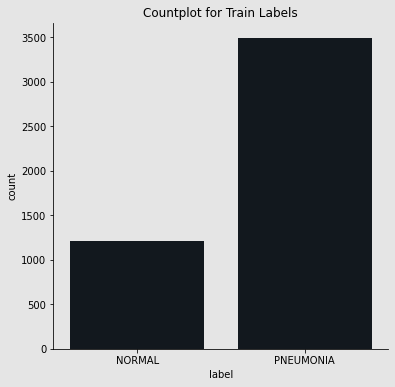

In [7]:
fig, ax = plt.subplots(figsize = (6, 6), facecolor = "#e5e5e5")
ax.set_facecolor("#e5e5e5")

sns.countplot(data = train_data, x = "label", ax = ax, color = "#101820")

ax.set_title("Countplot for Train Labels")

sns.despine()
plt.show()

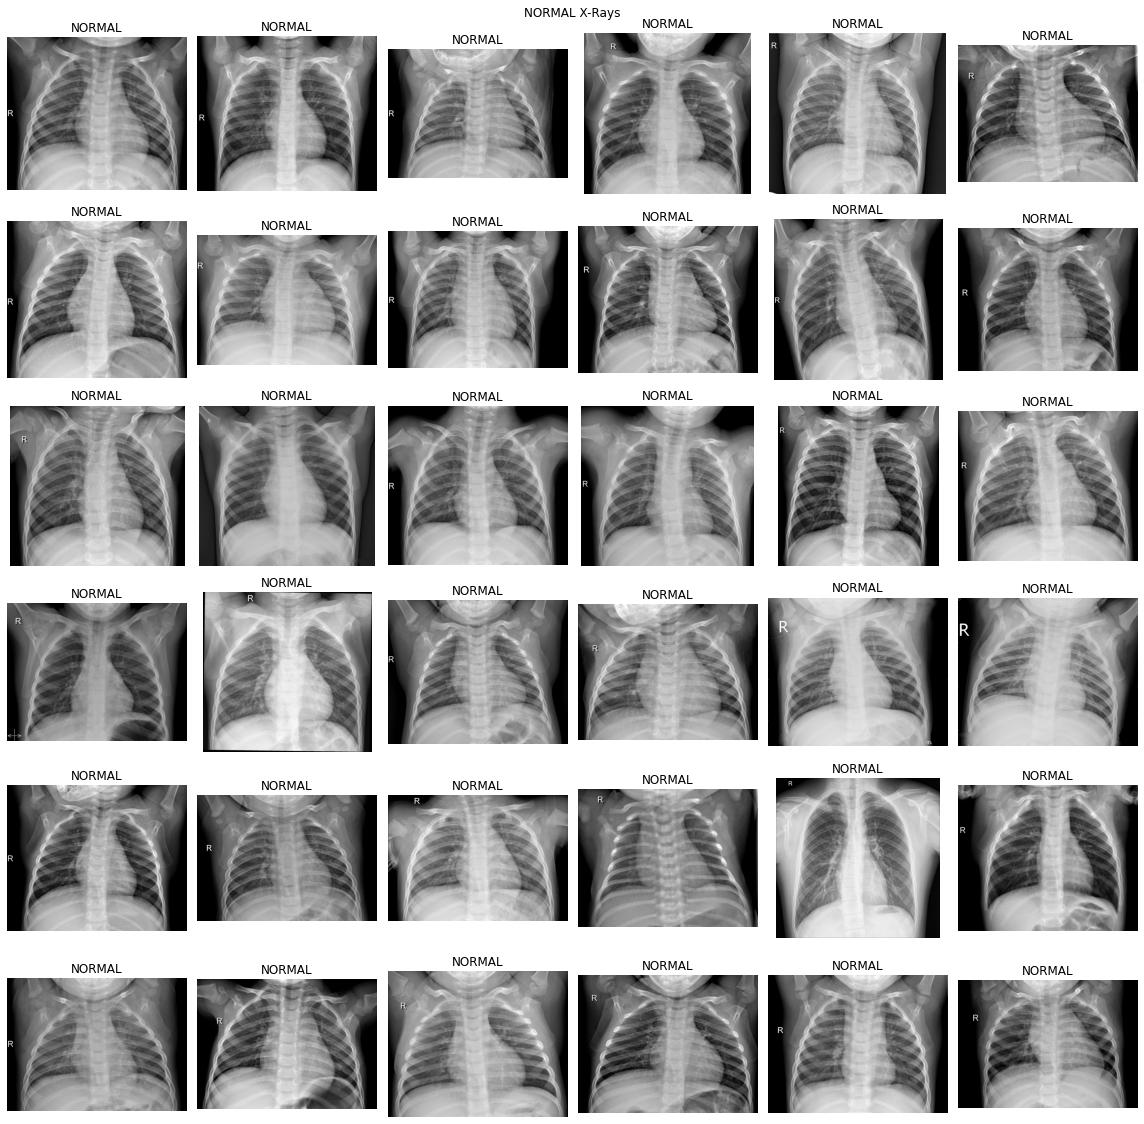

In [8]:
fig = plt.figure(1, figsize = (16, 16))
fig.suptitle("NORMAL X-Rays")

for i in range(36):
    
    ind = random.randint(0, len(train_data.query("label == 'NORMAL'")))

    plt.subplot(6, 6, i + 1)
    image = load_img(train_data.query("label == 'NORMAL'").reset_index()["path"][ind])
    plt.imshow(image)
    plt.title(train_data.query("label == 'NORMAL'").reset_index()["label"][ind])
    plt.axis("off")
    
plt.tight_layout()
plt.show()

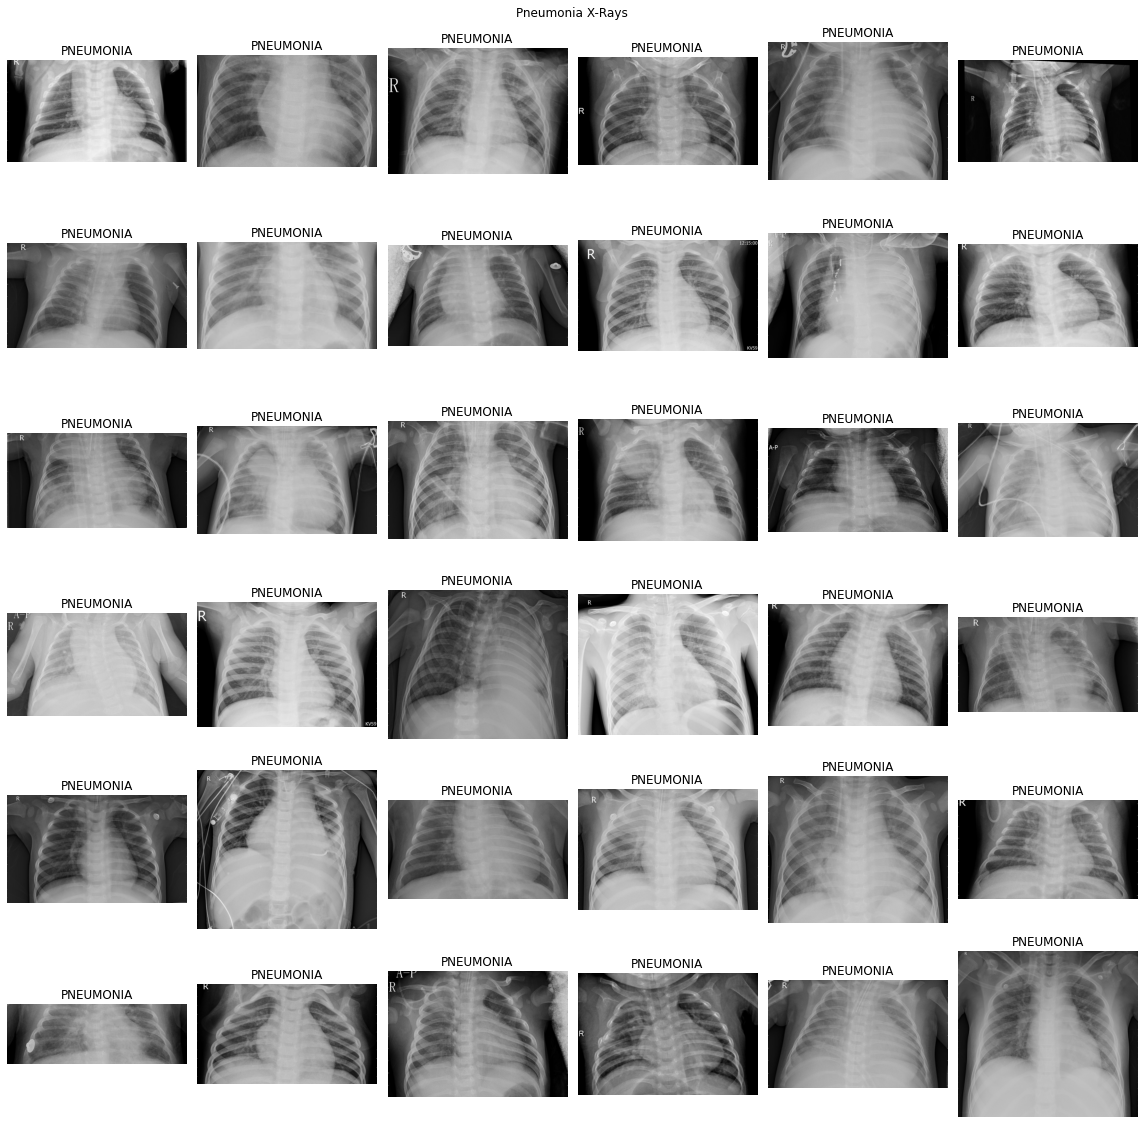

In [9]:
fig = plt.figure(1, figsize = (16, 16))
fig.suptitle("Pneumonia X-Rays")

for i in range(36):
    
    ind = random.randint(0, len(train_data.query("label == 'PNEUMONIA'")))

    plt.subplot(6, 6, i + 1)
    image = load_img(train_data.query("label == 'PNEUMONIA'").reset_index()["path"][ind])
    plt.imshow(image)
    plt.title(train_data.query("label == 'PNEUMONIA'").reset_index()["label"][ind])
    plt.axis("off")
    
plt.tight_layout()
plt.show()

# Data Augmentation

Found 1 validated image filenames belonging to 1 classes.


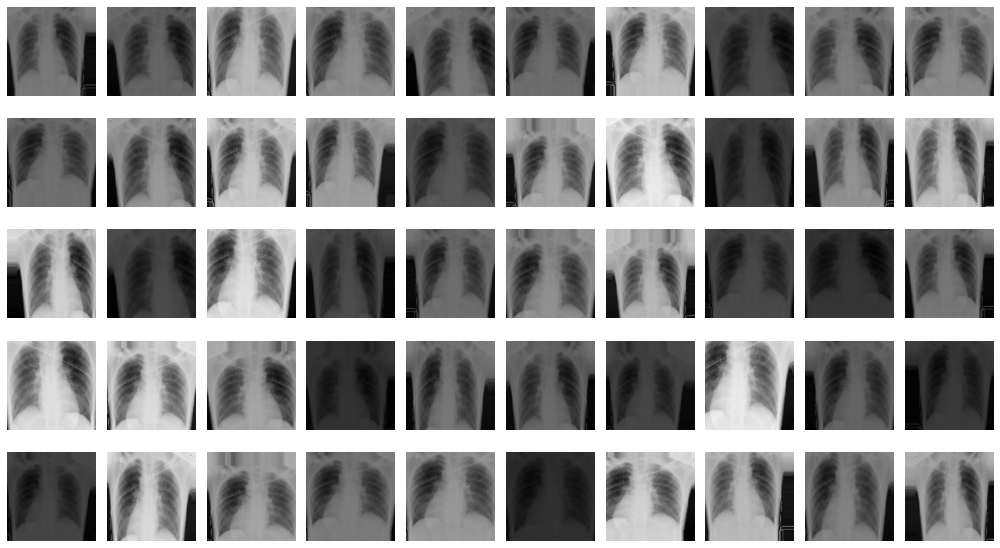

In [10]:
datagen = ImageDataGenerator(
    brightness_range = (0.2, 1), 
    zoom_range = 0.2,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    rescale = 1./255
)

sample_df = train_data.sample(1)

sample_generator = datagen.flow_from_dataframe(
    dataframe = sample_df,
    x_col = "path",
    y_col = "label",
    class_mode = "categorical",
    target_size = (150, 150),
    seed = 666
)

plt.figure(figsize = (14, 8))

for i in range(50):
    
    plt.subplot(5, 10, i + 1)
    
    for X, y in sample_generator:

        plt.imshow(X[0])
        plt.axis("off")
        break
        
plt.tight_layout()
plt.show()

In [11]:
train_datagen = ImageDataGenerator(
    brightness_range = (0.2, 1), 
    zoom_range = 0.2,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    preprocessing_function = preprocess_input
)

val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

In [12]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_data,
    x_col = "path",
    y_col = "label",
    target_size = (150, 150),
    class_mode = "categorical",
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = SEED
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe = val_data,
    x_col = "path",
    y_col = "label",
    target_size = (150, 150),
    class_mode = "categorical",
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = SEED
)

test_generator = test_datagen.flow_from_directory(
    directory = TEST_PATH,
    target_size = (150, 150),
    class_mode = "categorical",
    batch_size = BATCH_SIZE,
    shuffle = False,
    seed = SEED
)

Found 4694 validated image filenames belonging to 2 classes.
Found 538 validated image filenames belonging to 2 classes.
Found 624 images belonging to 2 classes.


# Transfer Learning with DenseNet121 Model

I chose DenseNet121 with respect to belowe discussion.

https://www.kaggle.com/c/ranzcr-clip-catheter-line-classification/discussion/212856

In [13]:
class_weights = compute_class_weight("balanced", classes = np.unique(train_data.label), y = train_data.label)

class_weights = {0: class_weights[0], 1: class_weights[1]}

In [14]:
base_model = DenseNet121(include_top = False, weights = "imagenet", input_shape = (150, 150, 3))

    
def dense121_pretrained():
    
    model = Sequential(
        [
            base_model,
            Flatten(),
            Dense(128, activation = "relu"),
            Dropout(0.25),
            Dense(2, activation = "softmax")
        ]
    )
    
    return model

2021-11-30 18:37:20.355895: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-30 18:37:20.459543: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-30 18:37:20.460216: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-30 18:37:20.461879: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

29097984/29084464 [==============================] - 1s 0us/step


In [15]:
tf.keras.backend.clear_session()

model = dense121_pretrained()

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
densenet121 (Functional)     (None, 4, 4, 1024)        7037504   
_________________________________________________________________
flatten (Flatten)            (None, 16384)             0         
_________________________________________________________________
dense (Dense)                (None, 128)               2097280   
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 258       
Total params: 9,135,042
Trainable params: 9,051,394
Non-trainable params: 83,648
_________________________________________________________________


In [16]:
reduce_lr = ReduceLROnPlateau(
    monitor = "val_accuracy", 
    patience = 2,
    verbose = 1, 
    factor = 0.3, 
    min_lr = 0.000000001,
    cooldown = 1
)

early_stopping = EarlyStopping(
    monitor = "val_accuracy",
    patience = 10,
    verbose = 1,
    mode = "max",
)

checkpoint = ModelCheckpoint(
    monitor = "val_accuracy",
    filepath = "pneumonia_densenet121_.{epoch:02d}-{val_accuracy:.6f}.hdf5",
    verbose = 1,
    save_best_only = True, 
    save_weights_only = True
)

model.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics = "accuracy")

history = model.fit(
    train_generator,
    epochs = 50, 
    batch_size = BATCH_SIZE,
    validation_data = val_generator,
    validation_steps = val_data.shape[0] // BATCH_SIZE,
    steps_per_epoch = train_data.shape[0] // BATCH_SIZE,
    callbacks = [reduce_lr, early_stopping, checkpoint],
    class_weight = class_weights
)

2021-11-30 18:37:28.416170: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/50


2021-11-30 18:37:39.842445: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


146/146 [==============================] - 134s 801ms/step - loss: 0.6269 - accuracy: 0.8623 - val_loss: 1.8238 - val_accuracy: 0.7520

Epoch 00001: val_accuracy improved from -inf to 0.75195, saving model to pneumonia_densenet121_.01-0.751953.hdf5
Epoch 2/50
146/146 [==============================] - 77s 528ms/step - loss: 0.1923 - accuracy: 0.9365 - val_loss: 0.8240 - val_accuracy: 0.7812

Epoch 00002: val_accuracy improved from 0.75195 to 0.78125, saving model to pneumonia_densenet121_.02-0.781250.hdf5
Epoch 3/50
146/146 [==============================] - 78s 531ms/step - loss: 0.1712 - accuracy: 0.9294 - val_loss: 0.3253 - val_accuracy: 0.8086

Epoch 00003: val_accuracy improved from 0.78125 to 0.80859, saving model to pneumonia_densenet121_.03-0.808594.hdf5
Epoch 4/50
146/146 [==============================] - 78s 533ms/step - loss: 0.2466 - accuracy: 0.9056 - val_loss: 0.6481 - val_accuracy: 0.7324

Epoch 00004: val_accuracy did not improve from 0.80859
Epoch 5/50
146/146 [======

In [17]:
tf.keras.backend.clear_session()

model = dense121_pretrained()

model.load_weights("./pneumonia_densenet121_.14-0.955078.hdf5")

# Learning Curves

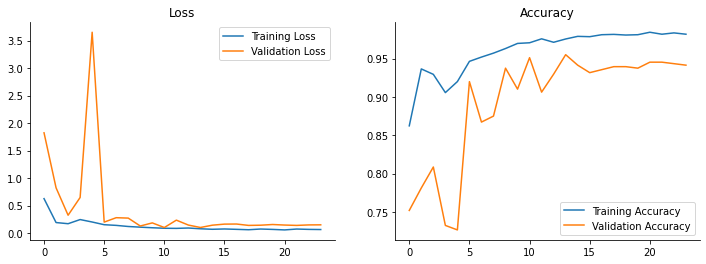

In [18]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.lineplot(x = range(len(history.history["loss"])), y = history.history["loss"], ax = axes[0], label = "Training Loss")
sns.lineplot(x = range(len(history.history["loss"])), y = history.history["val_loss"], ax = axes[0], label = "Validation Loss")

sns.lineplot(x = range(len(history.history["accuracy"])), y = history.history["accuracy"], ax = axes[1], label = "Training Accuracy")
sns.lineplot(x = range(len(history.history["accuracy"])), y = history.history["val_accuracy"], ax = axes[1], label = "Validation Accuracy")
axes[0].set_title("Loss"); axes[1].set_title("Accuracy")

sns.despine()
plt.show()

# Validation Set Performance

In [19]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe = val_data,
    x_col = "path",
    y_col = "label",
    target_size = (150, 150),
    class_mode = "categorical",
    batch_size = BATCH_SIZE,
    shuffle = False,
    seed = SEED
)

Found 538 validated image filenames belonging to 2 classes.


In [20]:
val_pred = model.predict(val_generator, steps = np.ceil(val_data.shape[0] / BATCH_SIZE))
val_data.loc[:, "val_pred"] = np.argmax(val_pred, axis = 1)

labels = dict((v, k) for k, v in val_generator.class_indices.items())

val_data.loc[:, "val_pred"] = val_data.loc[:, "val_pred"].map(labels)

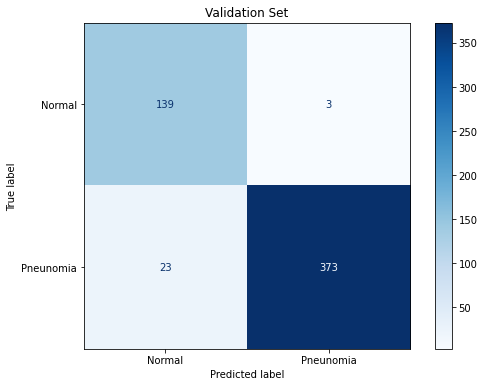

In [21]:
fig, ax = plt.subplots(figsize = (9, 6))

cm = confusion_matrix(val_data["label"], val_data["val_pred"])

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Normal", "Pneunomia"])
disp.plot(cmap = plt.cm.Blues, ax = ax)

ax.set_title("Validation Set")
plt.show()

In [22]:
print(classification_report(val_data["label"], val_data["val_pred"]))

              precision    recall  f1-score   support

      NORMAL       0.86      0.98      0.91       142
   PNEUMONIA       0.99      0.94      0.97       396

    accuracy                           0.95       538
   macro avg       0.93      0.96      0.94       538
weighted avg       0.96      0.95      0.95       538



# Test Set Performance

In [23]:
test_normal = pd.DataFrame({"path": os.listdir(TEST_PATH + "/NORMAL"), "label": "NORMAL"})
test_normal["path"] = test_normal["path"].apply(lambda x: TEST_PATH + "/NORMAL/" + x)
test_pneumonia = pd.DataFrame({"path": os.listdir(TEST_PATH + "/PNEUMONIA"), "label": "PNEUMONIA"})
test_pneumonia["path"] = test_pneumonia["path"].apply(lambda x: TEST_PATH + "/PNEUMONIA/" + x)

test_df = pd.concat([test_normal, test_pneumonia])

In [24]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col = "path",
    y_col = "label",
    target_size = (150, 150),
    class_mode = "categorical",
    batch_size = 1,
    shuffle = False,
    seed = SEED
)

Found 624 validated image filenames belonging to 2 classes.


In [25]:
test_pred = model.predict(test_generator)
test_df.loc[:, "test_pred"] = np.argmax(test_pred, axis = 1)

labels = dict((v, k) for k, v in test_generator.class_indices.items())

test_df.loc[:, "test_pred"] = test_df.loc[:, "test_pred"].map(labels)

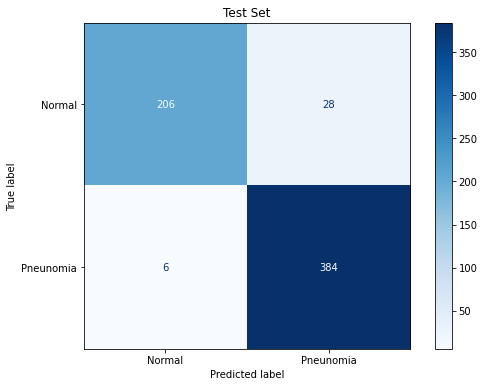

In [26]:
fig, ax = plt.subplots(figsize = (9, 6))

cm = confusion_matrix(test_df["label"], test_df["test_pred"])

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Normal", "Pneunomia"])
disp.plot(cmap = plt.cm.Blues, ax = ax)

ax.set_title("Test Set")
plt.show()

In [27]:
print(classification_report(test_df["label"], test_df["test_pred"]))

              precision    recall  f1-score   support

      NORMAL       0.97      0.88      0.92       234
   PNEUMONIA       0.93      0.98      0.96       390

    accuracy                           0.95       624
   macro avg       0.95      0.93      0.94       624
weighted avg       0.95      0.95      0.94       624



# Conclusion

For medical problems, especially imbalanced ones, accuracy is not best metric. We need to give priority to precision and recall. For this problem, recall is ratio of successfully detected pneumonia observations over all pneumonia observations.

Shortly, false negatives have bigger cost.

We have good score for both precision and recall. Our model for performs well.

# Readings & Resources

https://paperswithcode.com/method/densenet

https://www.kaggle.com/c/ranzcr-clip-catheter-line-classification/discussion/212856

https://www.kaggle.com/jonaspalucibarbosa/chest-x-ray-pneumonia-cnn-transfer-learning

https://www.kaggle.com/madz2000/pneumonia-detection-using-cnn-92-6-accuracy

https://www.kaggle.com/rajmehra03/a-comprehensive-guide-to-transfer-learning


My similar notebooks:

https://www.kaggle.com/mustafacicek/mnist-cnn-data-augmentation

https://www.kaggle.com/mustafacicek/mnist-lenet-5-implementation-on-keras

https://www.kaggle.com/mustafacicek/dogs-cats-vgg16-implementation-transfer-learning

https://www.kaggle.com/mustafacicek/alexnet-implementation-on-keras-flowers